# Dataset analysis (Beauty)

In [1]:
import csv
import json
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

## 1. Read .inter file

In [2]:
df = pd.read_csv('../../Amazon_Beauty/Amazon_Beauty.inter', sep='\t')

df.head(5)

,user_id:token,item_id:token,rating:float,timestamp:float
0,0,0,1.0,1391040000
1,1,0,3.0,1397779200
2,2,0,4.0,1378425600
3,3,0,2.0,1386460800
4,4,0,3.0,1382140800


## 2. K-core filtering

In [3]:
while True:
    shp = df.shape

    df = df.groupby("user_id:token").filter(lambda x: len(x) >= 5)
    df = df.groupby("item_id:token").filter(lambda x: len(x) >= 5)

    if df.shape == shp:
        break

    print(f"Number of unique items: {df['item_id:token'].nunique()}")
    print(f"Number of unique users: {df['user_id:token'].nunique()}")
    print(df.shape)

## 3. Analysis

### 3.1 Number of unique users & items

In [4]:
print(f"Number of unique items: {df['item_id:token'].nunique()}")
print(f"Number of unique users: {df['user_id:token'].nunique()}")
print(f"Number of unique reviews: {df.shape[0]}")

Number of unique items: 12101
Number of unique users: 22363
Number of unique reviews: 198502


### 3.2 Averages

In [5]:
print(f"Average rating: {df['rating:float'].sum() / df.shape[0]}")
print(f"Average interaction of user: {df.shape[0] / df['user_id:token'].nunique()}")
print(f"Average interaction of item: {df.shape[0] / df['item_id:token'].nunique()}")

Average rating: 4.190391028805755
Average interaction of user: 8.876358270357287
Average interaction of item: 16.403768283612923


### 3.3 Interaction matrix sparsity

In [6]:
print(f"Matrix sparsity: {(1.0 - (df.shape[0] / (df['item_id:token'].nunique() * df['user_id:token'].nunique())))*100}%")

Matrix sparsity: 99.92664772935825%


### 3.4 Top 10 reviewers

In [7]:
user_counts = df.groupby("user_id:token").size().reset_index(name="review_count")
user_counts.sort_values('review_count', ascending=False).head(10)

,user_id:token,review_count
995,995,204
2669,2669,192
178,178,182
1048,1048,154
746,746,150
1234,1234,149
413,413,149
6147,6147,131
5375,5375,123
224,224,119


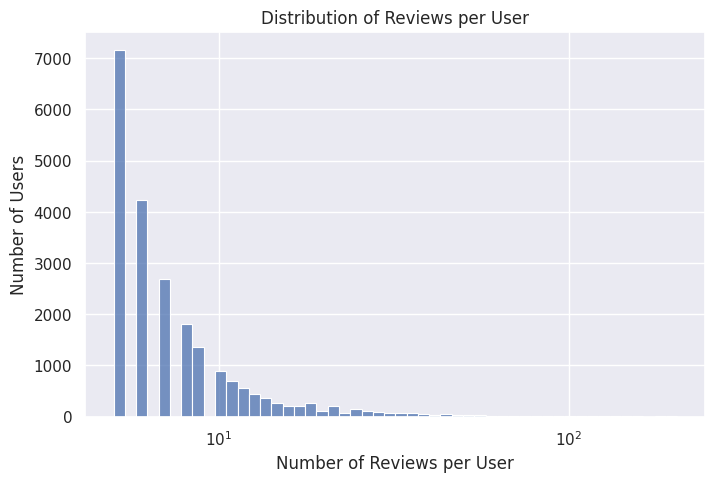

In [8]:
plt.figure(num=0, figsize=(8, 5))
sns.set_theme(style="darkgrid")

sns.histplot(
    user_counts['review_count'], 
    bins=50, log_scale=True
)

plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Reviews per User")

plt.show()

### 3.5 Top 10 reviewed items

In [9]:
product_counts = df.groupby(["item_id:token"]).size().reset_index(name="review_count")
product_counts.sort_values(by="review_count", ascending=False).head(10)

,item_id:token,review_count
7531,7531,431
6726,6726,403
8823,8823,391
2647,2647,389
2986,2986,329
6434,6434,328
8968,8968,321
10162,10162,310
9368,9368,305
267,267,302


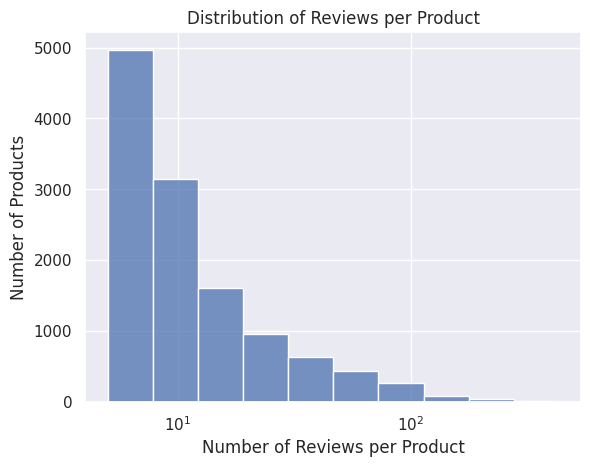

In [10]:
plt.figure(num=1)
sns.set_theme(style="darkgrid")

sns.histplot(
    data=product_counts['review_count'], 
    bins=10,
    log_scale=True
)

plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Distribution of Reviews per Product")

plt.show()

### 3.6 Item lifespan

In [11]:
lifespan_df = df.groupby(by='item_id:token')['timestamp:float'].agg(['min', 'max'])
lifespan_df['max'] = pd.to_datetime(lifespan_df['max'], unit='s')
lifespan_df['min'] = pd.to_datetime(lifespan_df['min'], unit='s')

lifespan_df['lifespan'] = lifespan_df['max'] - lifespan_df['min']
lifespan_df['lifespan'] = lifespan_df['lifespan'].dt.days

lifespan_df = lifespan_df[lifespan_df['lifespan'] != 0]
lifespan_df.head(5)

,min,max,lifespan
item_id:token,,,
0,2013-04-15,2014-04-18,368
1,2013-09-14,2014-07-13,302
2,2011-09-19,2013-08-10,691
3,2011-12-19,2014-03-11,813
4,2008-04-01,2014-06-08,2259


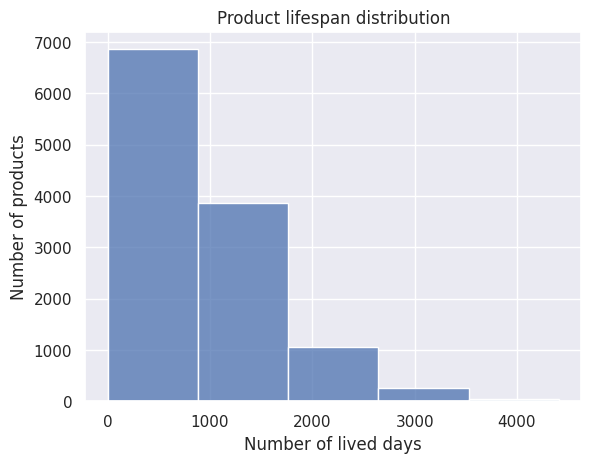

In [12]:
plt.figure(num=3)
sns.histplot(
    lifespan_df['lifespan'],
    log_scale=False,
    bins=5
)
plt.xlabel("Number of lived days")
plt.ylabel("Number of products")
plt.title("Product lifespan distribution")
plt.show()

### 3.7 Seasonality of items

In [13]:
seasonality_df = df.copy()
seasonality_df['timestamp:float'] = pd.to_datetime(seasonality_df['timestamp:float'], unit='s')
seasonality_df.set_index('timestamp:float', inplace=True)
seasonality_df.head()

,user_id:token,item_id:token,rating:float
timestamp:float,,,
2014-01-30,0,0,1.0
2014-04-18,1,0,3.0
2013-09-06,2,0,4.0
2013-12-08,3,0,2.0
2013-10-19,4,0,3.0


In [14]:
seasonality_df['verified_purchase'] = [True for _ in range(seasonality_df.shape[0])]
monthly_transaction_count = seasonality_df['verified_purchase'].resample('MS').count().reset_index(name="purchase_count")
monthly_transaction_count.head(10)

,timestamp:float,purchase_count
0,2002-06-01,3
1,2002-07-01,0
2,2002-08-01,0
3,2002-09-01,0
4,2002-10-01,0
5,2002-11-01,1
6,2002-12-01,0
7,2003-01-01,0
8,2003-02-01,0
9,2003-03-01,0


In [15]:
monthly_transaction_count.sort_values(by='purchase_count', ascending=False).head(20)

,timestamp:float,purchase_count
141,2014-03-01,9632
129,2013-03-01,9270
142,2014-04-01,8832
144,2014-06-01,8758
143,2014-05-01,8590
130,2013-04-01,8555
139,2014-01-01,8433
140,2014-02-01,8023
138,2013-12-01,7637
131,2013-05-01,7097


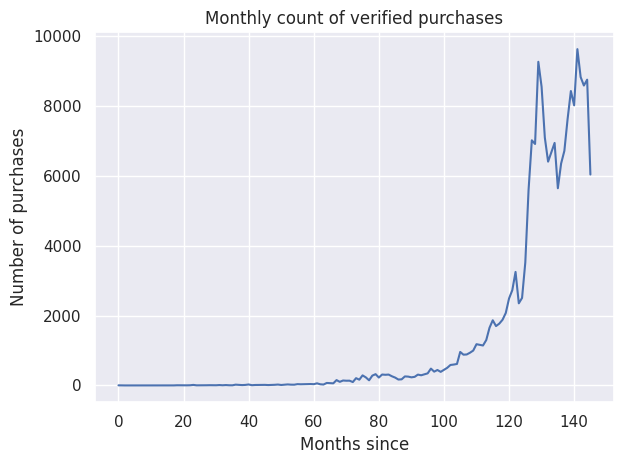

In [16]:
plt.figure(num=4)
monthly_transaction_count['purchase_count'].plot(title="Monthly count of verified purchases")
plt.xlabel('Months since')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.grid(True)
plt.show()

In [17]:
month_subseries_count = monthly_transaction_count.copy()
month_subseries_count['month'] = month_subseries_count['timestamp:float'].dt.month

foo = month_subseries_count.groupby(by='month')['purchase_count'].sum().reset_index(name='purchase_count')
foo.head(12)

,month,purchase_count
0,1,18707
1,2,17954
2,3,22441
3,4,20970
4,5,19517
5,6,19519
6,7,17377
7,8,12216
8,9,10084
9,10,11077


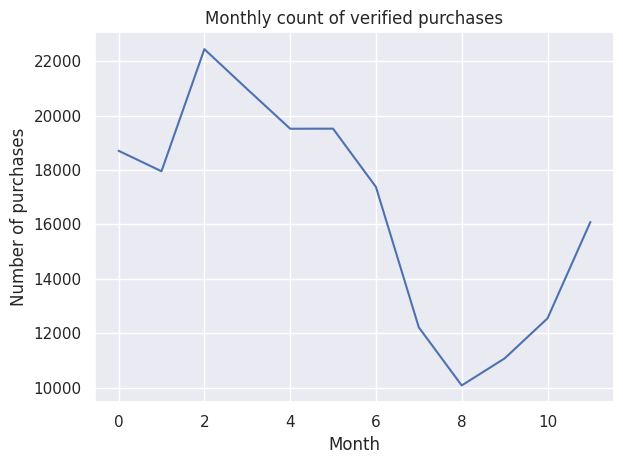

In [18]:
plt.figure(num=5)
foo['purchase_count'].plot(title="Monthly count of verified purchases")
plt.xlabel('Month')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.grid(True)
plt.show()

In [19]:
rating_counts = df['rating:float'].value_counts().sort_index()
rating_counts.head()

rating:float
1.0     10526
2.0     11456
3.0     22248
4.0     39741
5.0    114531
Name: count, dtype: int64

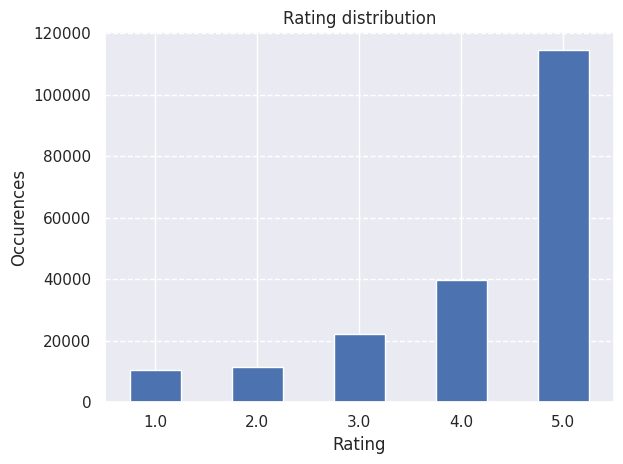

In [20]:
plt.figure(num=6)
rating_counts.plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Occurences')
plt.title('Rating distribution')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### 3.8 Subclasses

In [21]:
df2 = pd.read_csv('../../Amazon_Beauty/Amazon_Beauty.item', sep='\t')
df2.head(3)

,item_id:token,title:token,sales_type:token,sales_rank:float,categories:token_seq,price:float,brand:token
0,0,WAWO 15 Color Professionl Makeup Eyeshadow Cam...,Beauty,10486.0,"'Beauty', 'Makeup', 'Face', 'Concealers & Neut...",5.04,COKA
1,1,Xtreme Brite Brightening Gel 1oz.,Beauty,52254.0,"'Beauty', 'Hair Care', 'Styling Products', 'Cr...",19.99,Xtreme Brite
2,2,Prada Candy By Prada Eau De Parfum Spray 1.7 O...,Beauty,78916.0,"'Beauty', 'Fragrance', ""Women's"", 'Eau de Parfum'",65.86,Prada


In [22]:
subcategories_df = df2.dropna(subset=['categories:token_seq'])
subcategories_df.head(3)
subcategories_df['categories:token_seq'] = subcategories_df['categories:token_seq'].apply(lambda x: x.split(',')[1] if len(x.split(',')) > 1 else x.split(',')[0])
unique_parent_asins_in_subcategory = subcategories_df[['item_id:token', 'categories:token_seq']].drop_duplicates()
product_count_by_subcategory = unique_parent_asins_in_subcategory.groupby('categories:token_seq')['item_id:token'].count().sort_values(ascending=False)

In [23]:
product_count_by_subcategory.head(5)

categories:token_seq
'Skin Care'              3814
'Hair Care'              3262
'Makeup'                 2627
'Tools & Accessories'    1222
'Bath & Body'             684
Name: item_id:token, dtype: int64

In [24]:
top_n_subcategories = product_count_by_subcategory.head(20)
others_count = product_count_by_subcategory.iloc[20:].sum()

if others_count > 0:
    top_n_subcategories['Other'] = others_count

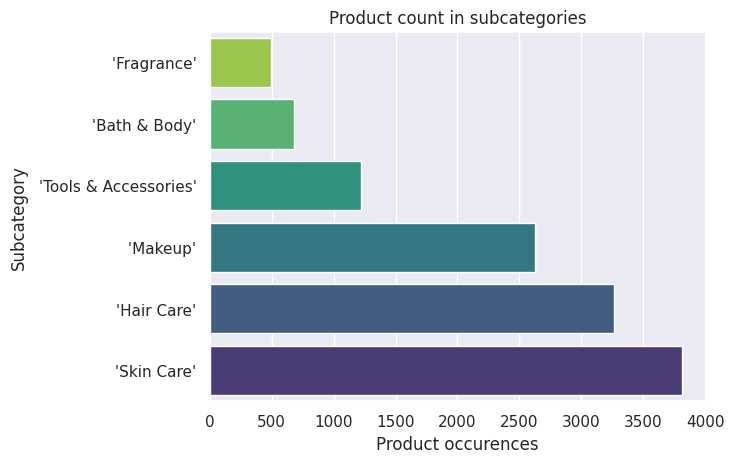

In [25]:
barplot = sns.barplot(x=top_n_subcategories.values, y=top_n_subcategories.index, palette="viridis", hue=top_n_subcategories.index, dodge=False, legend=False)
plt.xlabel('Product occurences')
plt.ylabel('Subcategory')
plt.title(f'Product count in subcategories')
plt.gca().invert_yaxis()